# BayesBench: Bayesian Early Stopping for a Recommender A/B Test

This notebook is a self-contained, runnable companion to the [BayesBench demo](https://github.com/rymarinelli/bayesbench-demo) Streamlit app, using an **MLOps-style A/B test** as the running example.

**The scenario:** you run a movie streaming service. Production currently serves a **popularity-based recommender** ("show everyone the most-rated movies"). Your team built a **candidate recommender** — item-item collaborative filtering, personalized per user — and wants to roll it out. Before flipping 100% of traffic to it, you run an online A/B test.

A fixed-horizon A/B test would commit to evaluating, say, 400 user sessions no matter what. **Bayesian sequential testing** instead re-checks the evidence after every session: it maintains a posterior belief over "P(candidate beats production)" and stops the test the moment that belief is confident enough — cutting the number of users exposed to the (possibly worse, or already-proven) losing model.

Critically, this isn't a one-shot offline comparison of two frozen models. **Both models keep learning from live traffic as the test runs** — a real recommender pipeline doesn't stop retraining just because an A/B test is in progress. In this notebook we:

1. Load real interaction data ([MovieLens ratings](https://huggingface.co/datasets/ashraq/movielens_ratings)) and split users into an **offline training pool** (fits both models initially, like a nightly batch job) and a **live-traffic pool** (simulates incoming user sessions for the A/B test).
2. Fit the **production model** (global popularity ranking) and the **candidate model** (item-item collaborative filtering with similarity shrinkage) on the training pool.
3. Score each live session with **Hit Rate@10**: did the model's top-10 list contain the movie this user went on to rate highly? A clean 0/1 outcome per session.
4. **Fold each session's outcome back into the training data and periodically retrain both models** — a continuous-training loop, so later sessions are scored by models that have seen more recent data than the ones scoring the first session.
5. Run a Beta-Bernoulli Bayesian sequential test over the stream of sessions, and stop as soon as the winner is decisive.

Everything runs on CPU in well under a minute — no GPU, no API keys, no model downloads.

In [1]:
# Uncomment if running in a fresh environment (e.g. Colab):
# %pip install -q datasets numpy pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

SEED = 42
N_MOVIES = 300            # keep the item catalog small enough for a dense similarity matrix
MIN_RATINGS = 8           # users need enough history to build a profile + hold one out
K = 10                    # recommend the top-10 movies
N_TRAIN_USERS = 12_000    # initial offline pool used to fit both models
N_EVAL_USERS = 400        # simulated live-traffic pool for the A/B test
FAVORITE_THRESHOLD = 4.0  # a rating >= this counts as "the user loved it"
SHRINKAGE_LAMBDA = 15.0   # discounts item-item similarity estimated from few co-raters
RETRAIN_EVERY = 50        # fold in new sessions and refit both models every N sessions
CONFIDENCE = 0.90         # stop as soon as P(candidate > production) or vice versa reaches this
CREDIBILITY = 0.95        # width of the reported credible interval

rng = np.random.default_rng(SEED)

## 1. Load ratings and split into offline / live-traffic pools

We restrict to the 300 most-rated movies (keeps the item-item matrix dense and fast to build) and to users with at least `MIN_RATINGS` ratings among them (enough history for a profile, plus one to hold out as the "session outcome"). Users are then split: most go into the **training pool** that fits the models offline; a held-out slice becomes the **live-traffic pool** the A/B test evaluates against — mirroring a real deploy where you train on historical logs and test on new, unseen sessions.

In [3]:
ds = load_dataset("ashraq/movielens_ratings", split="train")
ratings = ds.to_pandas()[["user_id", "movie_id", "rating", "title"]].drop_duplicates(["user_id", "movie_id"])
print(f"Total ratings: {len(ratings):,}")

top_movies = ratings["movie_id"].value_counts().head(N_MOVIES).index
ratings = ratings[ratings["movie_id"].isin(top_movies)]
movie_ids = sorted(top_movies.tolist())
movie_idx = {m: i for i, m in enumerate(movie_ids)}
movie_title = ratings.drop_duplicates("movie_id").set_index("movie_id")["title"].to_dict()

user_counts = ratings.groupby("user_id").size()
eligible_users = user_counts[user_counts >= MIN_RATINGS].index.to_numpy()
rng.shuffle(eligible_users)

train_users = eligible_users[:N_TRAIN_USERS]
eval_users = eligible_users[N_TRAIN_USERS:N_TRAIN_USERS + N_EVAL_USERS]
print(f"Movies in catalog: {len(movie_ids)}")
print(f"Offline training pool: {len(train_users):,} users")
print(f"Live-traffic pool: {len(eval_users):,} users")

Total ratings: 891,382


Movies in catalog: 300
Offline training pool: 12,000 users
Live-traffic pool: 400 users


## 2. Fit the two models (initial offline training)

- **Production — Popularity:** rank movies by how many pool users rated them. Same list for everyone; no personalization.
- **Candidate — Item-item collaborative filtering:** build a user-item rating matrix, compute item-item cosine similarity, and apply *similarity shrinkage* — discounting similarity scores estimated from only a handful of co-raters (a standard CF regularizer; without it, rarely-co-rated item pairs produce noisy, overconfident similarities that hurt recommendation quality).

We wrap this in a `fit_models()` function because we'll call it again later, every time fresh live-traffic data is folded back in.

In [4]:
def fit_models(ratings_pool):
    """Fit the candidate (item-item CF) and production (popularity) models on a ratings pool."""
    users = ratings_pool["user_id"].unique()
    user_idx = {u: i for i, u in enumerate(users)}

    R = np.zeros((len(users), len(movie_ids)), dtype=np.float32)
    for row in ratings_pool.itertuples(index=False):
        R[user_idx[row.user_id], movie_idx[row.movie_id]] = row.rating

    rated_mask = R != 0
    co_rating_count = rated_mask.T.astype(np.float32) @ rated_mask.astype(np.float32)
    item_norms = np.sqrt((R ** 2).sum(axis=0))
    item_norms[item_norms == 0] = 1e-9
    raw_cosine_sim = (R.T @ R) / np.outer(item_norms, item_norms)
    shrinkage = co_rating_count / (co_rating_count + SHRINKAGE_LAMBDA)
    item_similarity = raw_cosine_sim * shrinkage
    np.fill_diagonal(item_similarity, 0.0)

    popularity_rank = [
        movie_idx[m] for m in ratings_pool.groupby("movie_id").size().sort_values(ascending=False).index
    ]
    return item_similarity, popularity_rank


# The pool of "known" ratings the models are trained on. It starts as the offline
# training pool; run_ab_test() (Section 5) grows its own copy as live sessions arrive.
initial_known_ratings = ratings[ratings["user_id"].isin(train_users)].copy()
initial_item_similarity, initial_popularity_rank = fit_models(initial_known_ratings)

print(f"Item-item similarity matrix: {initial_item_similarity.shape}")
print(f"Fitted on {initial_known_ratings['user_id'].nunique():,} users")
print("Most popular movie in the training pool:", movie_title[movie_ids[initial_popularity_rank[0]]])

Item-item similarity matrix: (300, 300)
Fitted on 12,000 users
Most popular movie in the training pool: Guardians of the Galaxy (2014)


## 3. Score a live session — Hit Rate@10

For each live-traffic user we simulate a session: hide one movie they rated `>= FAVORITE_THRESHOLD` (the "outcome" of the session — what they actually wanted), show the model everything else in their history, and ask it to recommend `K` movies. A hit means the recommender surfaced the movie the user actually loved.

In [5]:
def simulate_session(user_id, eval_ratings, item_similarity, popularity_rank):
    user_ratings = eval_ratings[eval_ratings["user_id"] == user_id]
    favorites = user_ratings[user_ratings["rating"] >= FAVORITE_THRESHOLD]
    if favorites.empty:
        return None

    target = favorites.sample(1, random_state=int(user_id) % (2**32 - 1)).iloc[0]
    target_idx = movie_idx[target["movie_id"]]

    profile = user_ratings[user_ratings["movie_id"] != target["movie_id"]]
    profile_idx = [movie_idx[m] for m in profile["movie_id"]]
    profile_ratings = profile["rating"].to_numpy()
    if not profile_idx:
        return None

    # Candidate: weighted sum of similarities to the user's rated movies
    cf_scores = item_similarity[:, profile_idx] @ profile_ratings
    cf_scores[profile_idx] = -np.inf  # never re-recommend something already seen
    cf_topk = set(np.argsort(-cf_scores)[:K])
    cf_hit = 1.0 if target_idx in cf_topk else 0.0

    # Production: same popularity list for everyone, minus what they've already seen
    pop_topk = []
    for idx in popularity_rank:
        if idx in profile_idx:
            continue
        pop_topk.append(idx)
        if len(pop_topk) == K:
            break
    pop_hit = 1.0 if target_idx in set(pop_topk) else 0.0

    return cf_hit, pop_hit


MODEL_A_NAME, MODEL_B_NAME = "Candidate (item-item CF)", "Production (popularity)"

## 4. Bayesian sequential test

Each session's hit/miss is a Bernoulli trial. We keep a `Beta(alpha, beta)` posterior over each model's true hit rate, starting from an uninformative `Beta(1, 1)` prior, and update it after every session. `P(candidate > production)` is Monte Carlo-estimated by sampling from both posteriors; we stop the test the moment that probability (or its complement) crosses `CONFIDENCE`.

In [6]:
def bayesian_sequential_test(scores_a, scores_b, confidence, credibility, mc_samples=10_000, seed=0):
    rng = np.random.default_rng(seed)
    alpha_a = beta_a = 1.0
    alpha_b = beta_b = 1.0
    trace = []
    winner = None
    stopped_at = len(scores_a)

    for i, (sa, sb) in enumerate(zip(scores_a, scores_b)):
        alpha_a += sa; beta_a += 1 - sa
        alpha_b += sb; beta_b += 1 - sb

        samp_a = rng.beta(alpha_a, beta_a, mc_samples)
        samp_b = rng.beta(alpha_b, beta_b, mc_samples)
        p_a_beats_b = float((samp_a > samp_b).mean())

        trace.append({
            "session": i + 1,
            "p_a_beats_b": p_a_beats_b,
            "mean_a": alpha_a / (alpha_a + beta_a),
            "mean_b": alpha_b / (alpha_b + beta_b),
        })

        if winner is None:
            if p_a_beats_b >= confidence:
                winner, stopped_at = "A", i + 1
                break
            if p_a_beats_b <= 1 - confidence:
                winner, stopped_at = "B", i + 1
                break

    samp_a = rng.beta(alpha_a, beta_a, mc_samples)
    samp_b = rng.beta(alpha_b, beta_b, mc_samples)
    tail = (1 - credibility) / 2 * 100

    result = {
        "winner": winner,
        "p_a_beats_b": float((samp_a > samp_b).mean()),
        "mean_a": alpha_a / (alpha_a + beta_a),
        "mean_b": alpha_b / (alpha_b + beta_b),
        "ci_a": (float(np.percentile(samp_a, tail)), float(np.percentile(samp_a, 100 - tail))),
        "ci_b": (float(np.percentile(samp_b, tail)), float(np.percentile(samp_b, 100 - tail))),
        "sessions_used": stopped_at,
        "sessions_planned": len(scores_a),
        "efficiency": 1 - stopped_at / len(scores_a) if len(scores_a) else 0.0,
    }
    return result, trace

## 5. Run the A/B test — with continuous retraining

We replay the live-traffic pool in a fixed (shuffled) order, as if sessions arrived one at a time. `run_ab_test()` does this for a given retraining cadence:

1. Score both models with their **current** parameters (`item_similarity`, `popularity_rank`).
2. Once the outcome is known (the user did or didn't engage with the recommendation), fold that user's full rating history into the pool — this is new training signal, exactly like a production event log growing in real time.
3. Every `retrain_every` sessions, call `fit_models()` again on the updated pool and swap in the refreshed models for the next batch of sessions.

Passing a `retrain_every` larger than the whole live-traffic pool means step 3 never fires — the models stay frozen at their initial fit. We'll use that in Section 7 to check whether the retraining is actually earning its keep. We still collect the full stream first so the notebook always has data to plot, then run the sequential test over it; that's equivalent to actually stopping (and no longer retraining) the moment `sessions_used` is reached.

In [7]:
eval_ratings = ratings[ratings["user_id"].isin(eval_users)]


def run_ab_test(retrain_every):
    pool = initial_known_ratings.copy()
    item_sim, pop_rank = initial_item_similarity, initial_popularity_rank

    scores_a, scores_b, retrain_points = [], [], []
    for user_id in eval_users:
        outcome = simulate_session(user_id, eval_ratings, item_sim, pop_rank)
        if outcome is None:
            continue
        scores_a.append(outcome[0])
        scores_b.append(outcome[1])

        # The session's outcome is now known — fold it into the training pool.
        pool = pd.concat([pool, eval_ratings[eval_ratings["user_id"] == user_id]], ignore_index=True)

        if len(scores_a) % retrain_every == 0:
            item_sim, pop_rank = fit_models(pool)
            retrain_points.append(len(scores_a))

    result, trace = bayesian_sequential_test(scores_a, scores_b, CONFIDENCE, CREDIBILITY)
    return {
        "scores_a": scores_a, "scores_b": scores_b,
        "retrain_points": retrain_points, "final_pool_users": pool["user_id"].nunique(),
        "result": result, "trace": trace,
    }


main_run = run_ab_test(RETRAIN_EVERY)
scores_a, scores_b = main_run["scores_a"], main_run["scores_b"]
retrain_points = main_run["retrain_points"]
result, trace = main_run["result"], main_run["trace"]

print(f"Simulated sessions: {len(scores_a)}")
print(f"Retrains performed: {len(retrain_points)}  (after sessions {retrain_points})")
print(f"Training pool grew from {N_TRAIN_USERS:,} to {main_run['final_pool_users']:,} users")
print(f"{MODEL_A_NAME} hit rate@{K}: {np.mean(scores_a):.3f}")
print(f"{MODEL_B_NAME} hit rate@{K}: {np.mean(scores_b):.3f}")

result

Simulated sessions: 395
Retrains performed: 7  (after sessions [50, 100, 150, 200, 250, 300, 350])
Training pool grew from 12,000 to 12,395 users
Candidate (item-item CF) hit rate@10: 0.443
Production (popularity) hit rate@10: 0.365


{'winner': 'A',
 'p_a_beats_b': 0.8976,
 'mean_a': 0.46774193548387094,
 'mean_b': 0.3548387096774194,
 'ci_a': (0.3444707376548735, 0.5901278288607935),
 'ci_b': (0.24038373718479975, 0.47571571957578423),
 'sessions_used': 60,
 'sessions_planned': 395,
 'efficiency': 0.8481012658227848}

## 6. Results — would you ship the candidate?

In [8]:
winner_name = MODEL_A_NAME if result["winner"] == "A" else MODEL_B_NAME if result["winner"] == "B" else "Inconclusive"
print(f"Winner: {winner_name}")
print(f"P({MODEL_A_NAME} > {MODEL_B_NAME}) = {result['p_a_beats_b']:.3f}")
print(f"Sessions used: {result['sessions_used']}/{result['sessions_planned']}  "
      f"({result['efficiency']:.1%} of the planned A/B test avoided)")
retrains_before_stop = sum(1 for rp in retrain_points if rp < result["sessions_used"])
print(f"Model retrains before the test stopped: {retrains_before_stop}")
print(f"{MODEL_A_NAME}: hit rate={result['mean_a']:.3f}  {int(CREDIBILITY*100)}% CI={result['ci_a']}")
print(f"{MODEL_B_NAME}: hit rate={result['mean_b']:.3f}  {int(CREDIBILITY*100)}% CI={result['ci_b']}")

if result["winner"] == "A":
    print("\n--> Ship the candidate: stop the test, promote it to 100% of traffic.")
elif result["winner"] == "B":
    print("\n--> Keep production: the candidate underperforms, don't roll it out.")
else:
    print("\n--> Inconclusive at this sample size: keep collecting sessions, or lower CONFIDENCE.")

Winner: Candidate (item-item CF)
P(Candidate (item-item CF) > Production (popularity)) = 0.898
Sessions used: 60/395  (84.8% of the planned A/B test avoided)
Model retrains before the test stopped: 1
Candidate (item-item CF): hit rate=0.468  95% CI=(0.3444707376548735, 0.5901278288607935)
Production (popularity): hit rate=0.355  95% CI=(0.24038373718479975, 0.47571571957578423)

--> Ship the candidate: stop the test, promote it to 100% of traffic.


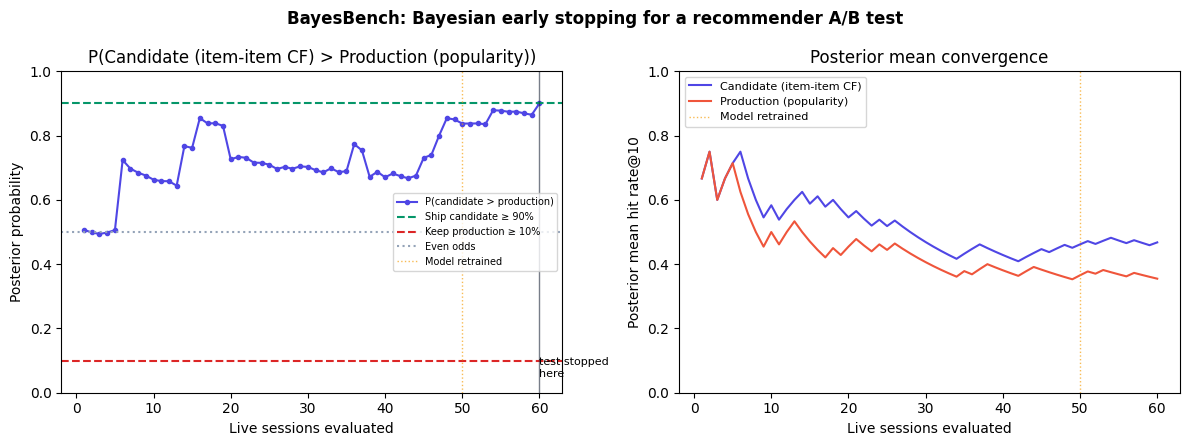

In [9]:
sessions = [t["session"] for t in trace]
p_curve = [t["p_a_beats_b"] for t in trace]
mean_a_curve = [t["mean_a"] for t in trace]
mean_b_curve = [t["mean_b"] for t in trace]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(sessions, p_curve, color="#4F46E5", marker="o", markersize=3, label="P(candidate > production)")
ax.axhline(CONFIDENCE, color="#059669", linestyle="--", label=f"Ship candidate ≥ {CONFIDENCE:.0%}")
ax.axhline(1 - CONFIDENCE, color="#DC2626", linestyle="--", label=f"Keep production ≥ {1 - CONFIDENCE:.0%}")
ax.axhline(0.5, color="#94A3B8", linestyle=":", label="Even odds")
for j, rp in enumerate(retrain_points):
    if rp <= max(sessions):
        ax.axvline(rp, color="#F59E0B", linestyle=":", linewidth=1, alpha=0.7,
                    label="Model retrained" if j == 0 else None)
if result["winner"] is not None:
    ax.axvline(result["sessions_used"], color="#1E293B", linestyle="-", linewidth=1, alpha=0.6)
    ax.annotate("test stopped\nhere", xy=(result["sessions_used"], 0.05), fontsize=8, ha="left")
ax.set_ylim(0, 1)
ax.set_xlabel("Live sessions evaluated")
ax.set_ylabel("Posterior probability")
ax.set_title(f"P({MODEL_A_NAME} > {MODEL_B_NAME})")
ax.legend(fontsize=7, loc="center right")

ax = axes[1]
ax.plot(sessions, mean_a_curve, color="#4F46E5", label=MODEL_A_NAME)
ax.plot(sessions, mean_b_curve, color="#EF553B", label=MODEL_B_NAME)
for j, rp in enumerate(retrain_points):
    if rp <= max(sessions):
        ax.axvline(rp, color="#F59E0B", linestyle=":", linewidth=1, alpha=0.7,
                    label="Model retrained" if j == 0 else None)
ax.set_ylim(0, 1)
ax.set_xlabel("Live sessions evaluated")
ax.set_ylabel(f"Posterior mean hit rate@{K}")
ax.set_title("Posterior mean convergence")
ax.legend(fontsize=8)

fig.suptitle("BayesBench: Bayesian early stopping for a recommender A/B test", fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Does retraining actually help?

Section 5 asserted that continuous retraining makes this closer to a real production system, but didn't measure whether it changes the outcome. Let's check directly: replay the **identical** live-traffic stream (same users, same shuffle, same held-out "favorite" per user — nothing here is re-randomized) under two policies:

- **Static** — `retrain_every` set larger than the whole live-traffic pool, so both models stay frozen at their initial fit for the entire test.
- **Continuously retrained** — the `RETRAIN_EVERY`-session cadence used above.

Any difference in the numbers below is attributable to the extra ~0–350 sessions' worth of data each model got to train on, not to noise in which sessions were sampled.

In [10]:
static_run = run_ab_test(retrain_every=10**9)  # never fires within N_EVAL_USERS sessions

def _summarize(run, label):
    r = run["result"]
    winner = MODEL_A_NAME if r["winner"] == "A" else MODEL_B_NAME if r["winner"] == "B" else "Inconclusive"
    return {
        "policy": label,
        f"{MODEL_A_NAME} hit rate": np.mean(run["scores_a"]),
        f"{MODEL_B_NAME} hit rate": np.mean(run["scores_b"]),
        "winner": winner,
        "sessions_used": r["sessions_used"],
        "sessions_planned": r["sessions_planned"],
    }

comparison = pd.DataFrame([
    _summarize(static_run, "Static (no retraining)"),
    _summarize(main_run, f"Continuously retrained (every {RETRAIN_EVERY})"),
]).set_index("policy")
comparison

,Candidate (item-item CF) hit rate,Production (popularity) hit rate,winner,sessions_used,sessions_planned
policy,,,,,
Static (no retraining),0.445570,0.362025,Candidate (item-item CF),60,395
Continuously retrained (every 50),0.443038,0.364557,Candidate (item-item CF),60,395


In [11]:
cand_delta = np.mean(main_run["scores_a"]) - np.mean(static_run["scores_a"])
prod_delta = np.mean(main_run["scores_b"]) - np.mean(static_run["scores_b"])
speed_delta = static_run["result"]["sessions_used"] - main_run["result"]["sessions_used"]

print(f"Candidate hit-rate change from retraining: {cand_delta:+.3f}")
print(f"Production hit-rate change from retraining: {prod_delta:+.3f}")
print(f"Sessions-to-decision change from retraining: {speed_delta:+d} "
      f"({'faster' if speed_delta > 0 else 'slower' if speed_delta < 0 else 'no change'})")

if abs(cand_delta) < 0.02 and abs(speed_delta) <= 5:
    print(
        "\nAt this data scale (~50 sessions between retrains, on a mature 12,000-user "
        "training pool) retraining makes little measurable difference here -- the pool "
        "barely moves as a fraction of what the models were already fit on. That's a "
        "real, useful finding: it tells you retraining cadence isn't the lever to pull "
        "in this regime. The mechanism still matters in settings with faster drift or a "
        "smaller/colder initial training pool, where each new batch of sessions is a much "
        "larger fraction of what the model knows."
    )
else:
    print(
        "\nRetraining measurably changed the outcome here -- evidence that, even at this "
        "scale, keeping the models fed with live data is doing real work."
    )

Candidate hit-rate change from retraining: -0.003
Production hit-rate change from retraining: +0.003
Sessions-to-decision change from retraining: +0 (no change)

At this data scale (~50 sessions between retrains, on a mature 12,000-user training pool) retraining makes little measurable difference here -- the pool barely moves as a fraction of what the models were already fit on. That's a real, useful finding: it tells you retraining cadence isn't the lever to pull in this regime. The mechanism still matters in settings with faster drift or a smaller/colder initial training pool, where each new batch of sessions is a much larger fraction of what the model knows.


## Why this matters for MLOps

A fixed-horizon A/B test here would commit to 400 sessions regardless of how lopsided the result is. The Bayesian sequential test instead stops as soon as the posterior is confident — in a typical run that's a large majority of the planned traffic **never exposed to the losing model**, and a decision available in a fraction of the wall-clock time. For a real rollout that translates directly into less user-facing risk and a faster ship/no-ship call.

Layering continuous retraining on top makes the setup closer to a real production system: the models being compared aren't static artifacts frozen at deploy time, they're being updated by the same pipeline that's usually running against live event logs. Section 7 measured whether that actually changes anything here, rather than just asserting it — read those numbers, not this paragraph, for the honest answer at this data scale. The mechanism itself generalizes to systems with faster drift (trending content, seasonal demand, a cold-start-heavy user base) or a smaller/newer training pool, where each batch of live sessions is a much larger share of what the model knows — that's where a sequential test's ability to react to a model that's improving (or degrading) mid-test earns its keep over a fixed-horizon test decided in advance.

## Next steps

- Tighten or loosen `CONFIDENCE` to trade decision speed against certainty.
- Shrink `RETRAIN_EVERY` further, or shrink `N_TRAIN_USERS` so each retrain is a bigger relative jolt to the model — both make the effect measured in Section 7 easier to see.
- Swap `FAVORITE_THRESHOLD`, `K`, or `SHRINKAGE_LAMBDA` and watch the hit-rate gap (and the stopping point) move.
- Replace either model with your own — the sequential test only needs a `[0, 1]`-valued score per session, so it works unchanged for click-through, conversion, or any other online-metric A/B test.
- For the full interactive experience (multi-task suites, model ranking, agent/tool-use benchmarks, custom HF datasets), see the [Streamlit demo](https://github.com/rymarinelli/bayesbench-demo).
- The underlying package is [`bayesbench`](https://github.com/rymarinelli/bayesbench), which this notebook's `bayesian_sequential_test` mirrors in miniature.